In [68]:
import os 
import subprocess 

from dotenv import load_dotenv

from datasets import load_from_disk, load_dataset
import numpy as np
import matplotlib.pyplot as plt 
import scienceplots 

plt.style.use("muted")

load_dotenv() 

DATA_ROOT = os.getenv("DATA_ROOT")


latex_bin_path = f"{DATA_ROOT}/texlive_store/texlive/bin/x86_64-linux"
os.environ["PATH"] = latex_bin_path + os.pathsep + os.environ["PATH"]

# 3. Verify which version is being picked up
try:
    version = subprocess.check_output(["latex", "--version"]).decode().splitlines()[0]
    print(f"Using LaTeX version: {version}")
except Exception as e:
    print(f"Error finding LaTeX: {e}")

# Now enable LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})


model_no = "7374427_0"
fp = f"{DATA_ROOT}/hsc_embeddings/hsc_conditional_flow/embeddings/{model_no}"

data_files = {
    "train": f"{fp}/train/*.parquet",
    "val": f"{fp}/val/*.parquet",
    "test": f"{fp}/test/*.parquet"
}
ds_hsc_embeddings = load_dataset(
    "parquet",
    data_files=data_files
)

Using LaTeX version: pdfTeX 3.141592653-2.6-1.40.28 (TeX Live 2025)


In [69]:
ds_z = load_from_disk(
    f"{DATA_ROOT}/wwdc_catastrophic_z/metadata"
)

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2752069/1728856317.py:31: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Actual $\Delta z$", fontsize=14)
/tmp/ipykernel_2752069/1728856317.py:32: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Predicted $\Delta z$", fontsize=14)
/tmp/ipykernel_2752069/1728856317.py:33: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"Linear Regression on {embed_type} embedding: Predicted vs Actual $\Delta z$\n$R^2 = {r2:.3f}$", fontsize=16)


Mean Squared Error: 0.0155
R^2 Score: 0.0002


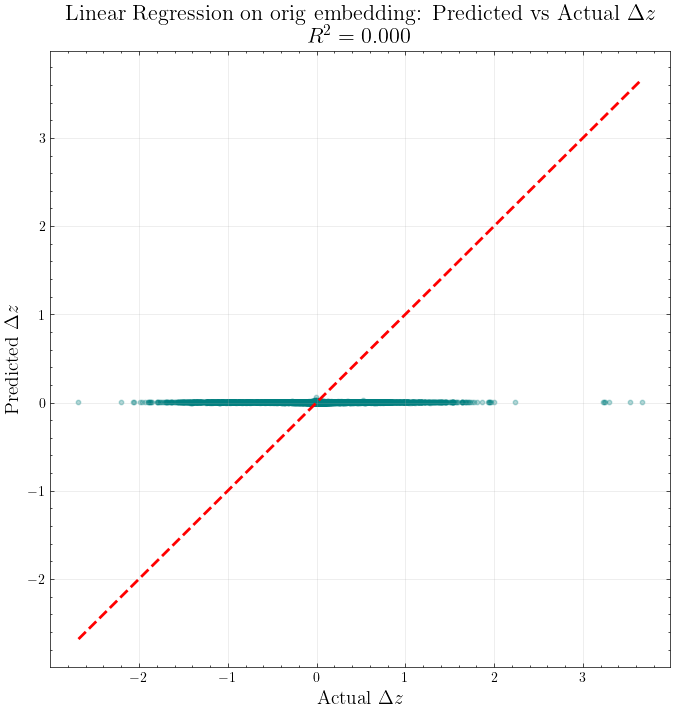

Mean Squared Error: 0.0155
R^2 Score: 0.0002


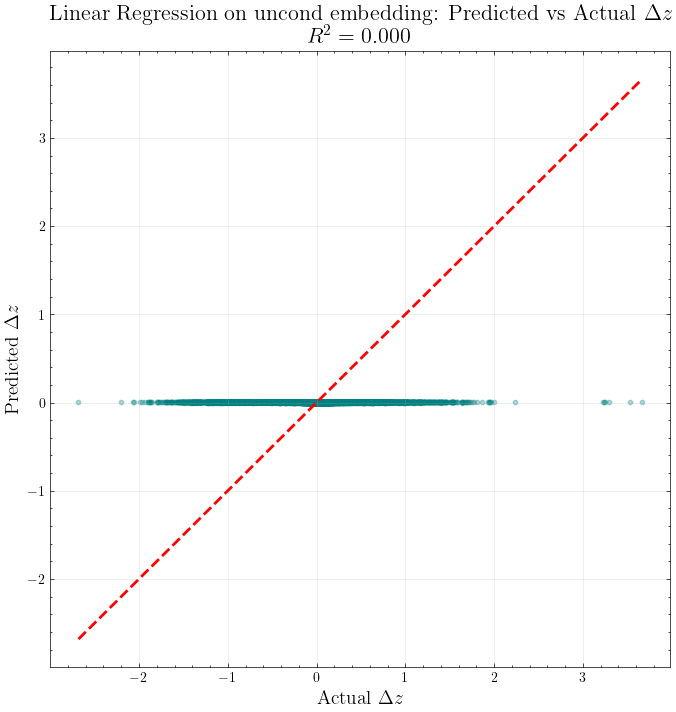

Mean Squared Error: 0.0155
R^2 Score: 0.0002


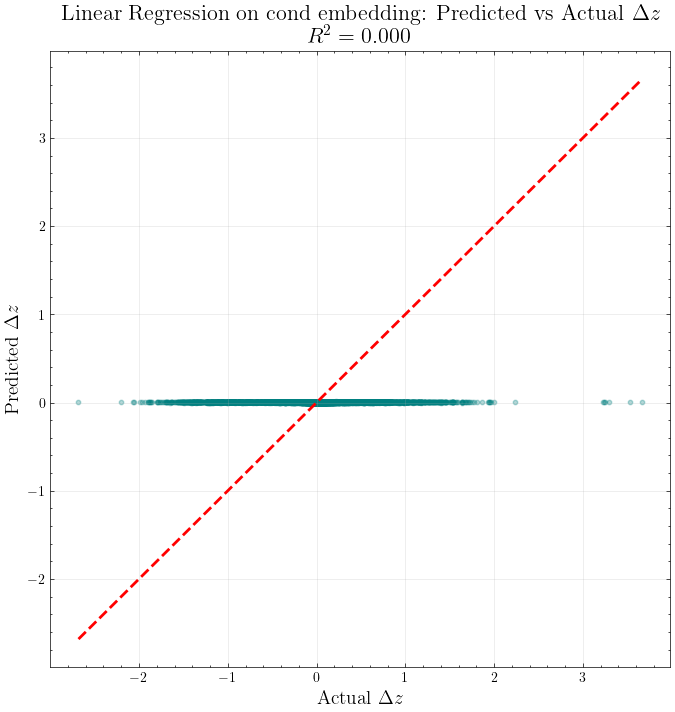

In [71]:
# 1. Prepare Data
# X = embeddings (features), y = delta_z (target)
split = "train"

for embed_type in ["orig", "uncond", "cond"]:
    X = np.array(ds_hsc_embeddings[split][embed_type])
    true_z = np.array(ds_z[split]["y_0"])
    predict_z = np.array(ds_z[split]["yhat_0"])

    delta_z = true_z - predict_z
    y = delta_z

    # 2. Train the Linear Regressor
    lr = LinearRegression()
    lr.fit(X, y)

    # 3. Predict and Evaluate
    y_pred = lr.predict(X)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R^2 Score: {r2:.4f}")

    # 4. Visualize Predicted vs. Actual
    plt.figure(figsize=(8, 8))
    plt.scatter(y, y_pred, alpha=0.3, s=10, c='teal')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Identity line

    plt.xlabel("Actual $\Delta z$", fontsize=14)
    plt.ylabel("Predicted $\Delta z$", fontsize=14)
    plt.title(f"Linear Regression on {embed_type} embedding: Predicted vs Actual $\Delta z$\n$R^2 = {r2:.3f}$", fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.show()

<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:50: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:50: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2752069/1579689582.py:48: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Actual $\Delta z$", fontsize=14)
/tmp/ipykernel_2752069/1579689582.py:49: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Predicted $\Delta z$", fontsize=14)
/tmp/ipykernel_2752069/1579689582.py:50: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"MLP Regressor on {embed_type} embedding: Predicted vs Actual $\Delta z$\n$R^2 = {r2_mlp:.3f}$", fontsize=16)


MLP Mean Squared Error: 0.0155
MLP R^2 Score: -0.0002


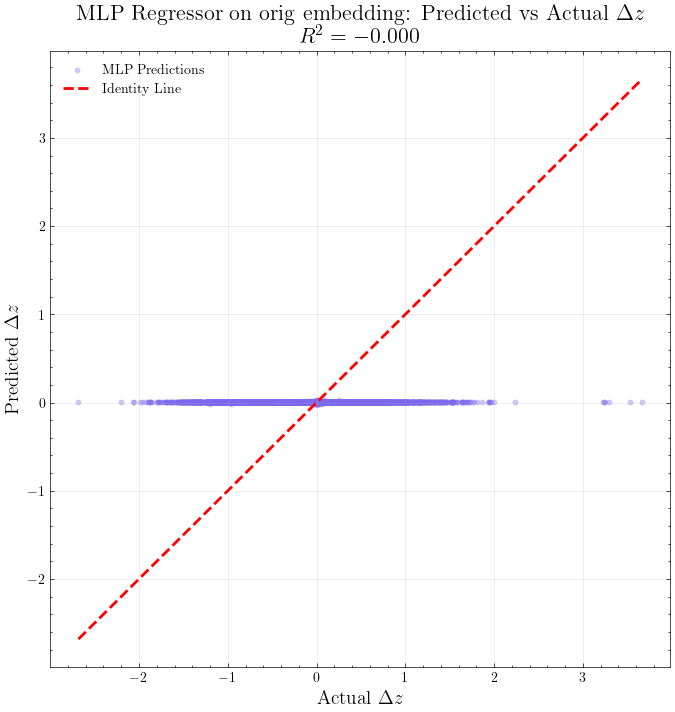

MLP Mean Squared Error: 0.0155
MLP R^2 Score: 0.0002


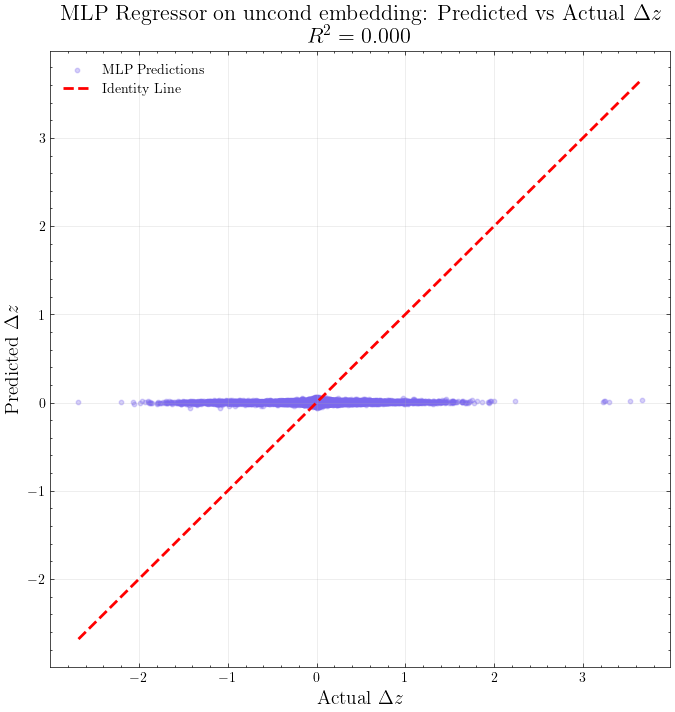

MLP Mean Squared Error: 0.0155
MLP R^2 Score: 0.0001


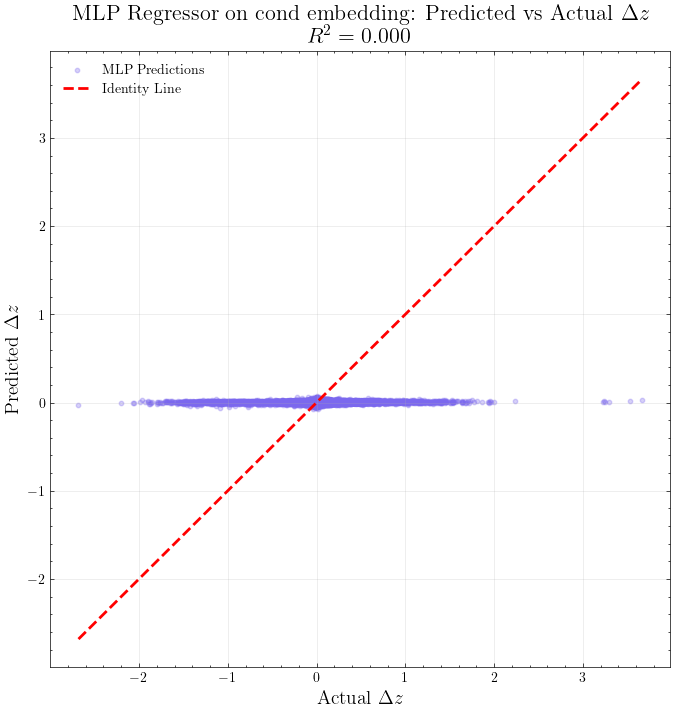

In [72]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


for embed_type in ["orig", "uncond", "cond"]:
    X = np.array(ds_hsc_embeddings[split][embed_type])
    true_z = np.array(ds_z[split]["y_0"])
    predict_z = np.array(ds_z[split]["yhat_0"])

    delta_z = true_z - predict_z
    y = delta_z

    # 1. Setup the MLP Pipeline
    # We use a pipeline to ensure scaling is handled correctly
    # architecture: (64, 32) means two hidden layers with 64 and 32 neurons
    mlp = make_pipeline(
        MLPRegressor(
            hidden_layer_sizes=(64, 64, 64), 
            activation='relu', 
            solver='adam', 
            max_iter=1000, 
            random_state=42,
            early_stopping=True # Prevents overfitting by watching validation loss
        )
    )

    # 2. Train the Model
    # Using the full set as requested, though typically we'd split
    mlp.fit(X, y)

    # 3. Predict and Evaluate
    y_pred_mlp = mlp.predict(X)

    mse_mlp = mean_squared_error(y, y_pred_mlp)
    r2_mlp = r2_score(y, y_pred_mlp)

    print(f"MLP Mean Squared Error: {mse_mlp:.4f}")
    print(f"MLP R^2 Score: {r2_mlp:.4f}")

    # 4. Visualize
    plt.figure(figsize=(8, 8))
    plt.scatter(y, y_pred_mlp, alpha=0.3, s=10, color='mediumslateblue', label='MLP Predictions')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Identity Line')

    plt.xlabel("Actual $\Delta z$", fontsize=14)
    plt.ylabel("Predicted $\Delta z$", fontsize=14)
    plt.title(f"MLP Regressor on {embed_type} embedding: Predicted vs Actual $\Delta z$\n$R^2 = {r2_mlp:.3f}$", fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot embeddings dimension by dimension

In [4]:
from scipy.stats import norm

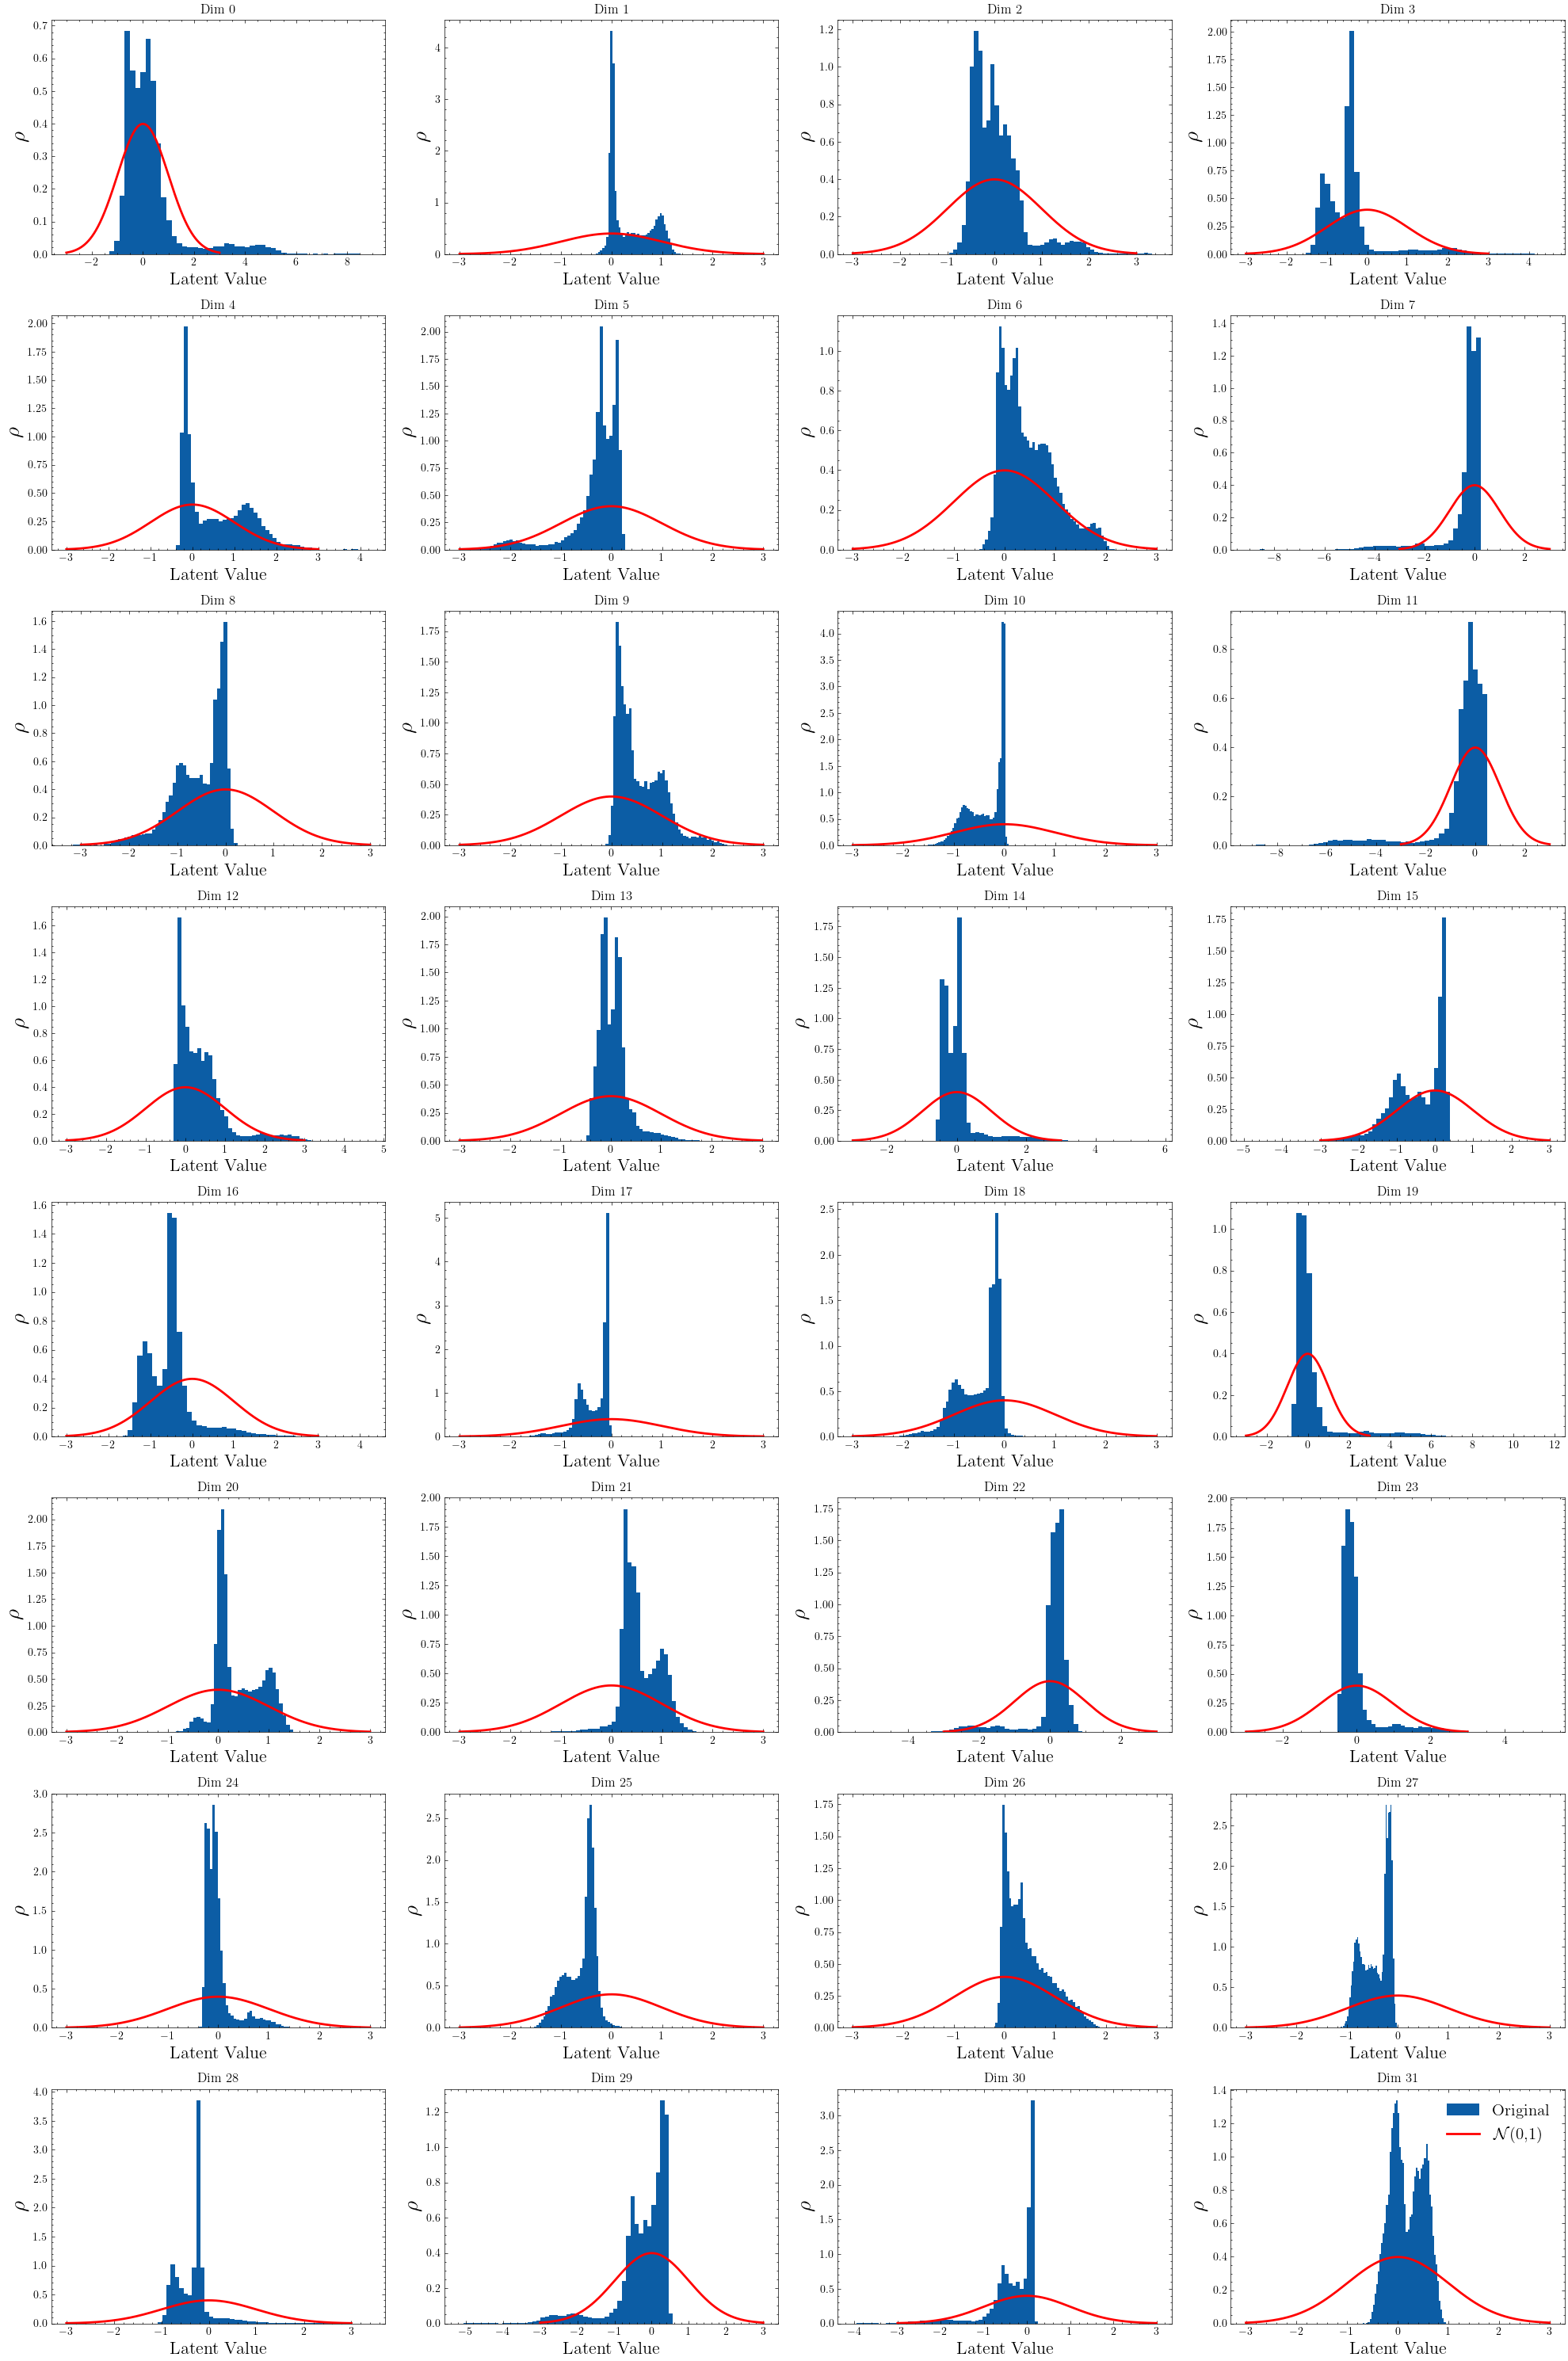

In [5]:
h = np.array(ds_hsc_embeddings["test"]["orig"])

N, D = h.shape

fig, axes = plt.subplots(8,4, figsize=(20, 30))
axes = axes.flatten()  # make indexing easier

x = np.linspace(-3, 3, 500)  # range for Gaussian

for i in range(D):
    axes[i].hist(h[:, i], bins=50, density=True, label="Original")
    axes[i].plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}$(0,1)')
    axes[i].set_title(f"Dim {i}")
    axes[i].set_xlabel("Latent Value", fontsize=16)
    axes[i].set_ylabel(r"$\rho$", fontsize=20)

plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

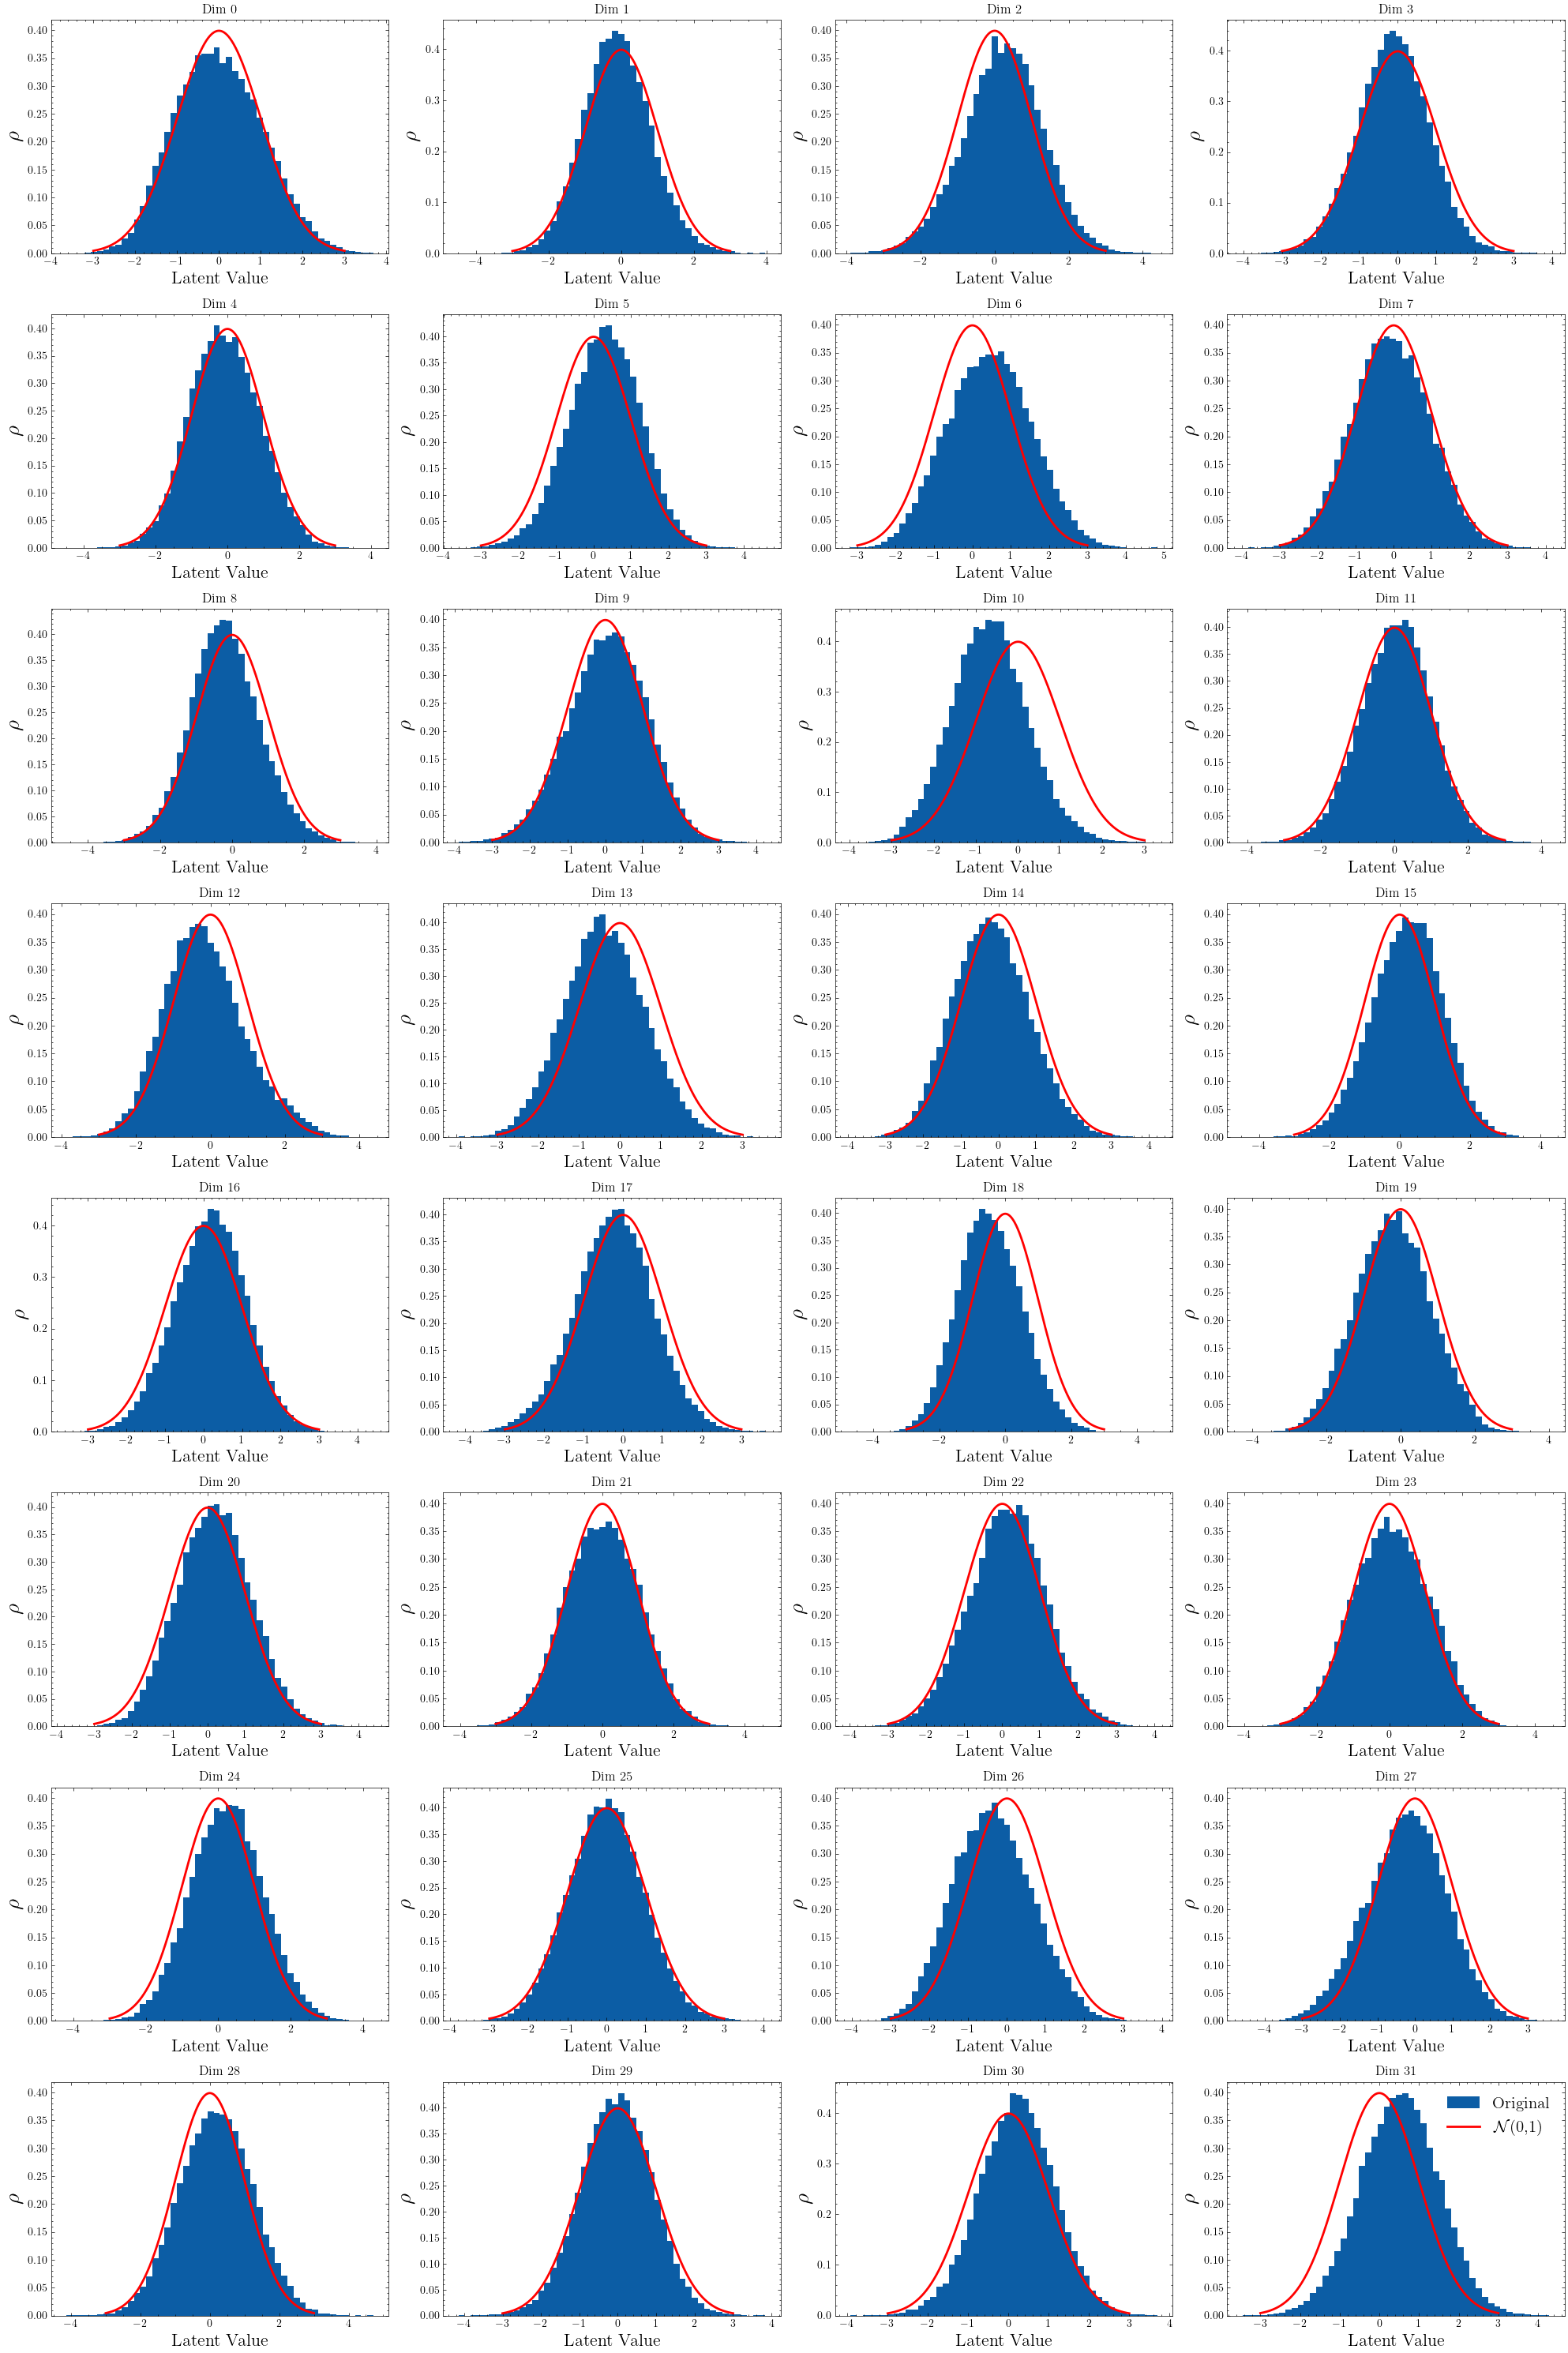

In [6]:
h = np.array(ds_hsc_embeddings["test"]["uncond"])

N, D = h.shape

fig, axes = plt.subplots(8,4, figsize=(20, 30))
axes = axes.flatten()  # make indexing easier

x = np.linspace(-3, 3, 500)  # range for Gaussian

for i in range(D):
    axes[i].hist(h[:, i], bins=50, density=True, label="Original")
    axes[i].plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}$(0,1)')
    axes[i].set_title(f"Dim {i}")
    axes[i].set_xlabel("Latent Value", fontsize=16)
    axes[i].set_ylabel(r"$\rho$", fontsize=20)

plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

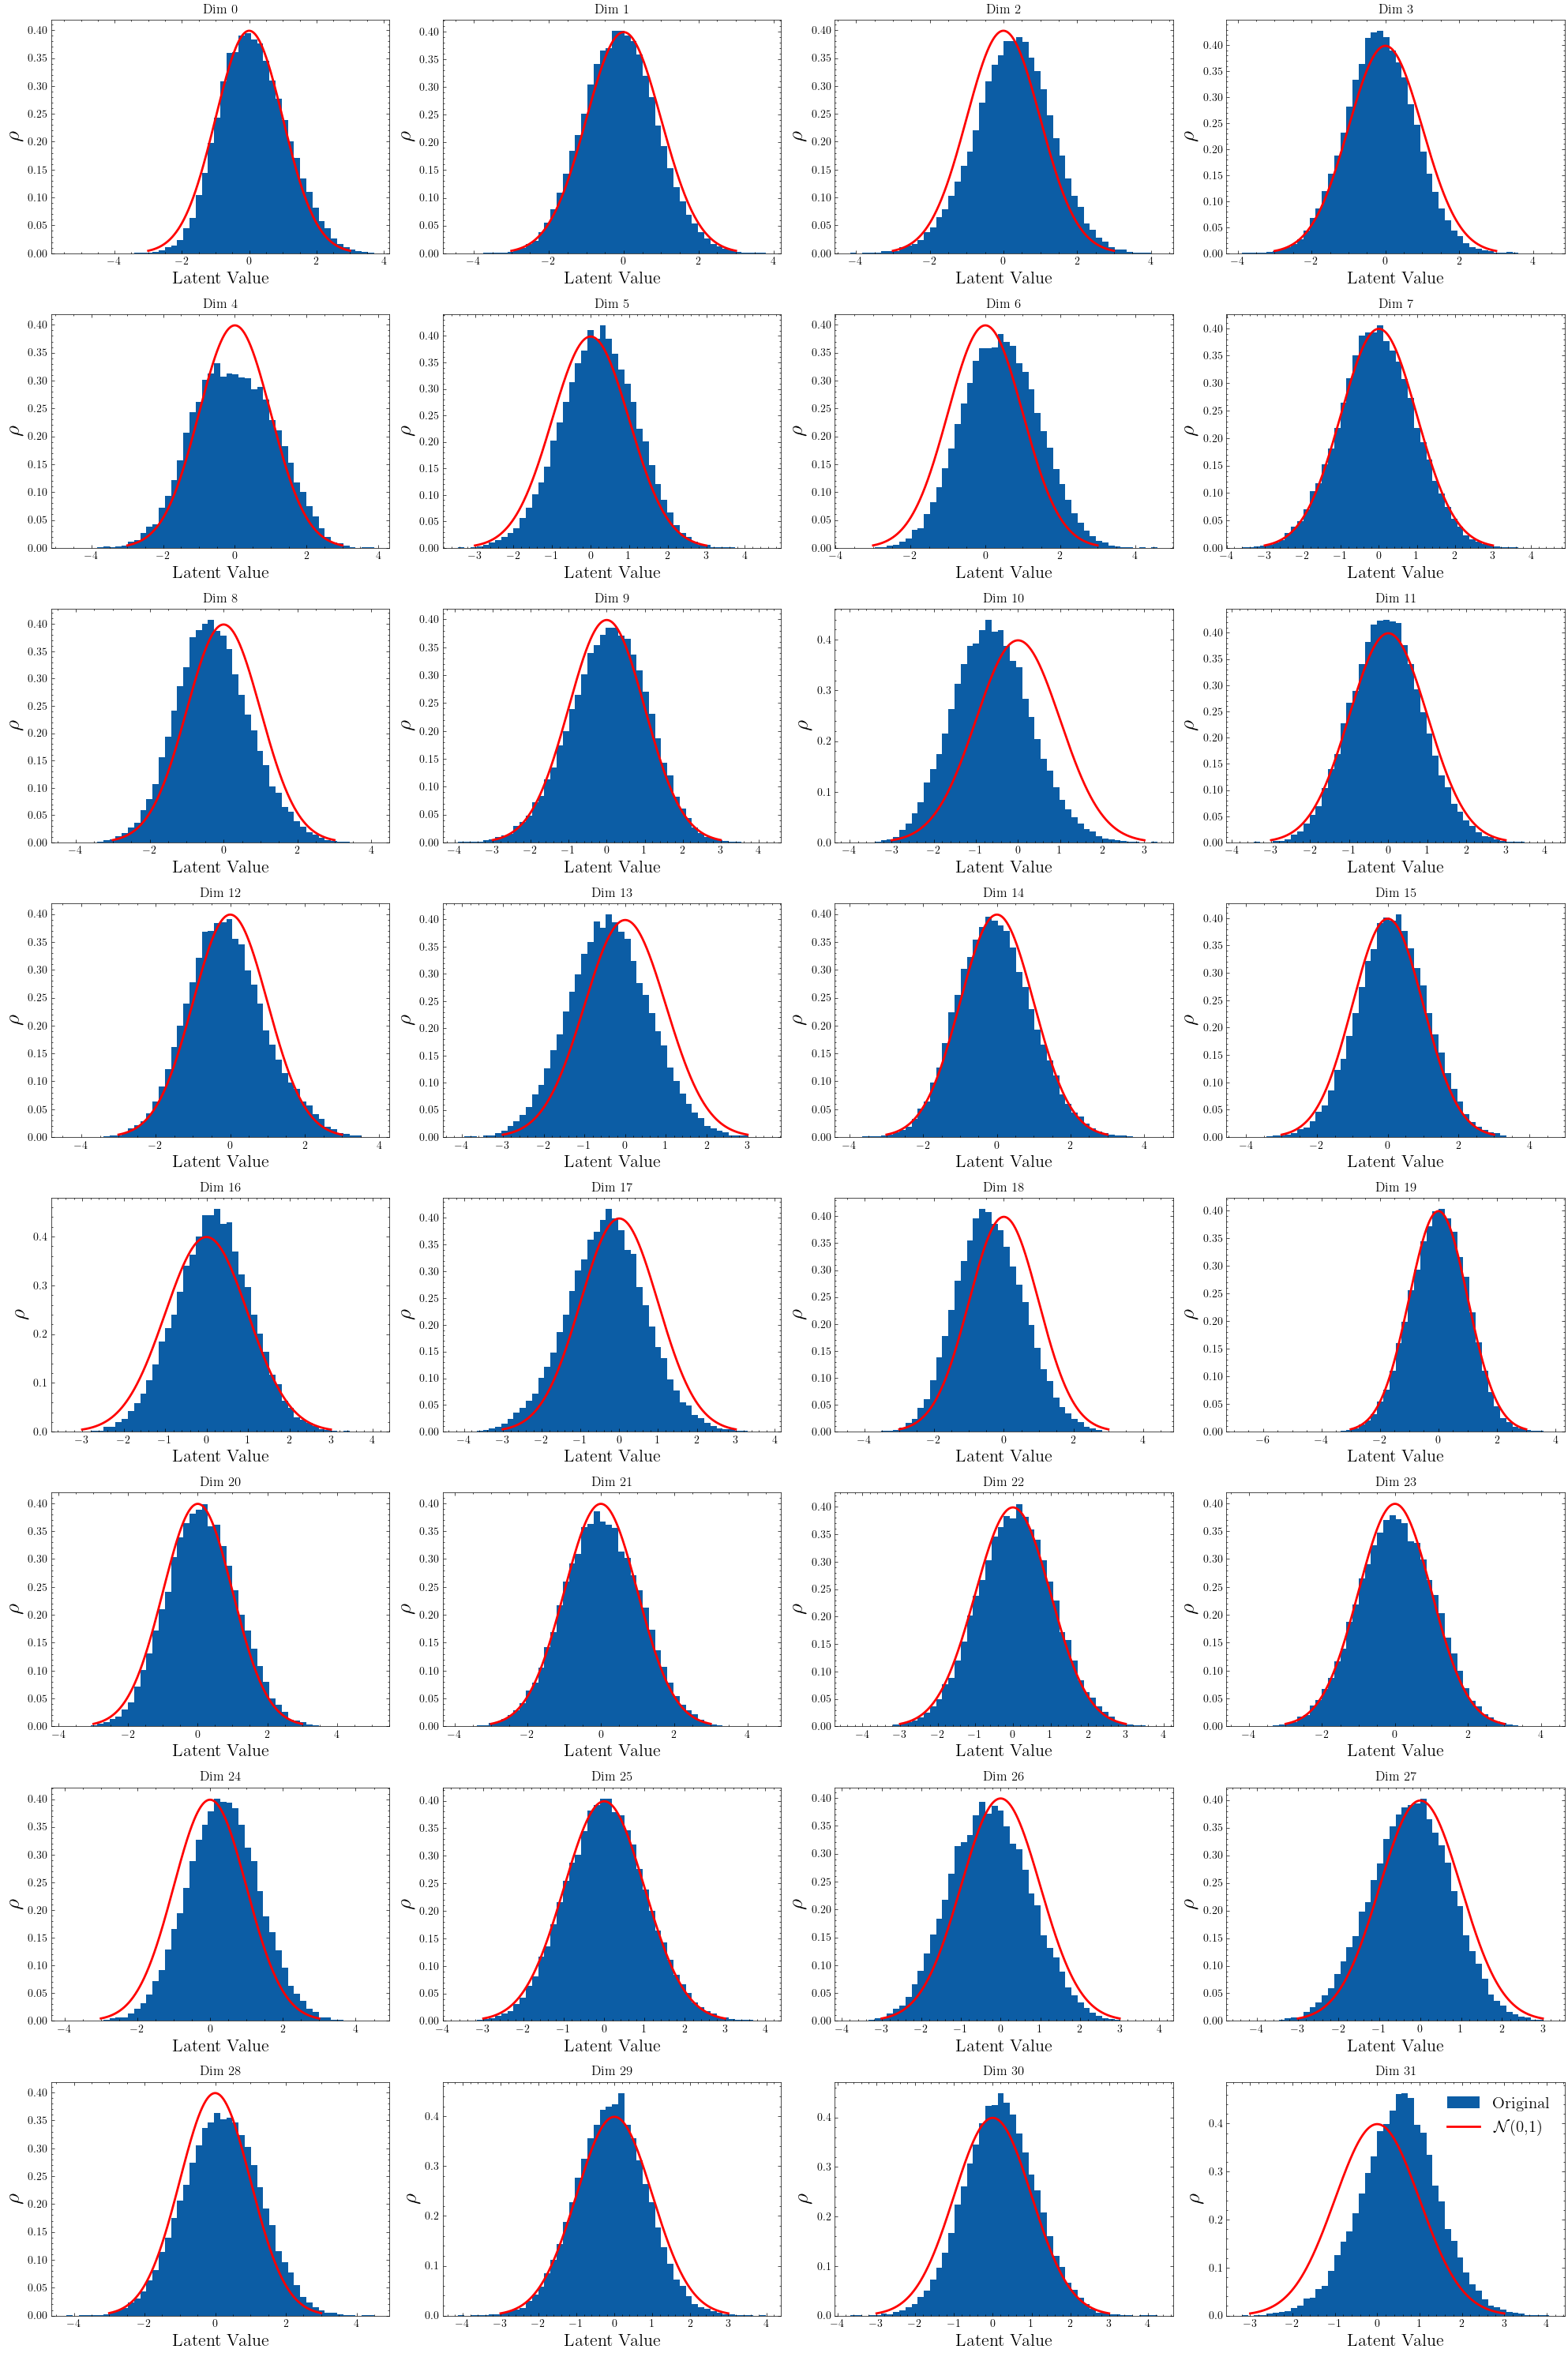

In [7]:
h = np.array(ds_hsc_embeddings["test"]["cond"])

N, D = h.shape

fig, axes = plt.subplots(8,4, figsize=(20, 30))
axes = axes.flatten()  # make indexing easier

x = np.linspace(-3, 3, 500)  # range for Gaussian

for i in range(D):
    axes[i].hist(h[:, i], bins=50, density=True, label="Original")
    axes[i].plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label=r'$\mathcal{N}$(0,1)')
    axes[i].set_title(f"Dim {i}")
    axes[i].set_xlabel("Latent Value", fontsize=16)
    axes[i].set_ylabel(r"$\rho$", fontsize=20)

plt.tight_layout()
plt.legend(fontsize=15)
plt.show()